In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import ticker
import seaborn as sns

from const import *

plt.style.use('default') # 重置
params = {
    'font.family': 'serif',        # 衬线体 (Times New Roman 等)
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'], # 显式指定
    'mathtext.fontset': 'stix',    # 数学公式字体更像 LaTeX
    'axes.labelsize': 14,
    'font.size': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.spines.top': False,      # 去掉顶部边框 (更简洁)
    'axes.spines.right': False,    # 去掉右侧边框
}
plt.rcParams.update(params)

In [3]:
from utilize.mesh_io import read_mshv2_triangular

node_pos_np, triangles = read_mshv2_triangular("pd_stretch_demo_mesh_init.msh")

cell_size = 0.5 * np.linalg.norm(np.cross(node_pos_np[triangles[:, 1]] - node_pos_np[triangles[:, 0]], node_pos_np[triangles[:, 2]] - node_pos_np[triangles[:, 0]]), axis=1)

sigma_k = np.loadtxt(f"P_diag_ekf.csv", delimiter=",")
raw_k = np.loadtxt(f"estimated_stiffness_ekf.csv", delimiter=",")
Y_k = np.loadtxt(f"Y_ekf.csv", delimiter=",")

high_uncertainty_indices_variance = np.loadtxt(f"high_uncertainty_indices_variance.csv", delimiter=",", dtype=int)

high_uncertainty_mask_variance = np.zeros(triangles.shape[0], dtype=bool)
high_uncertainty_mask_variance[high_uncertainty_indices_variance] = True

---
Variance Space

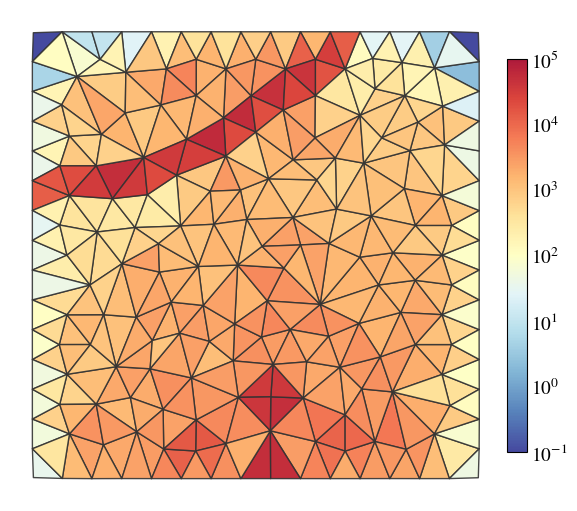

In [10]:
cmap_custom = sns.color_palette("RdYlBu_r", as_cmap=True)

variance = sigma_k.copy()
v_min, v_max = variance.min(), variance.max()
tick_locs = np.arange(np.ceil(np.log10(v_min)), np.floor(np.log10(v_max))+2)
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im1 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=np.log10(variance), shading='flat', 
                    edgecolors='#333333', linewidth=1., alpha=0.9, cmap=cmap_custom,    # 
                    vmin=tick_locs[0], vmax=tick_locs[-1])
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.046)
cbar1.ax.tick_params(length=0, labelsize=14)

cbar1.set_ticks(tick_locs)
cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs])

plt.savefig(f"stiffness_variance.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

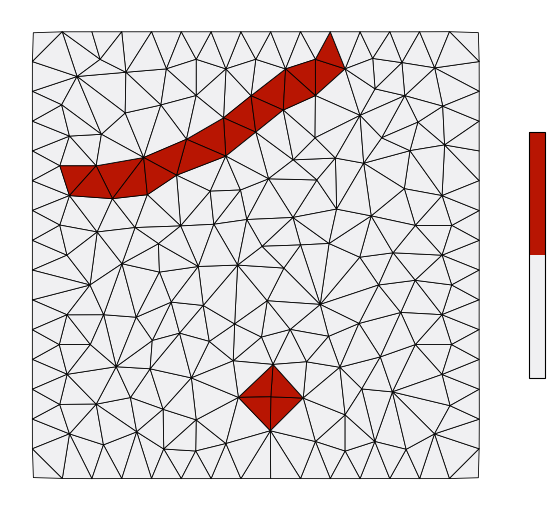

In [ ]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_uncertainty_mask_variance.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_variance.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

[Field Metric 1] ROC-AUC: 0.9834 (Closer to 1.0 is better)  
[Field Metric 2] Average Precision (PR-AUC): 0.6523 (Higher is better)  
[Field Metric 3] GT-based Log-CNR: 1.9820 (Higher means better signal contrast)  
[Field Metric 4] GT-based FDR: 3.5474 (Higher means better statistical separability)  
[Field Metric 5] GT-based Suppression Ratio: 4.5362 (Higher means target is relatively enhanced)

---
刚度空间

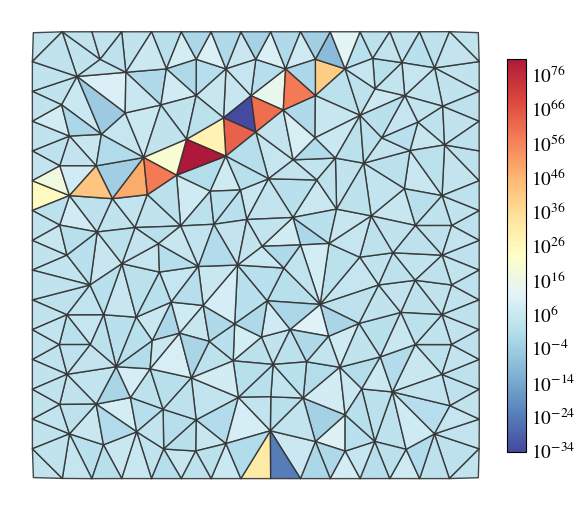

In [5]:
# 可视化刚度值
v_min, v_max = raw_k.min(), raw_k.max()
tick_locs = np.arange(np.ceil(np.log10(v_min)), np.floor(np.log10(v_max)))
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles,
                    facecolors=np.log10(raw_k), shading='flat', 
                    edgecolors='#333333', linewidth=1., alpha=0.9, cmap=cmap_custom,    # 
                    )
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.046)
cbar1.ax.tick_params(length=0, labelsize=14)

cbar1.set_ticks(tick_locs[::10])
cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs[::10]])

plt.savefig(f"stiffness_value.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

In [11]:
high_uncertainty_indices_value = np.loadtxt(f"high_uncertainty_indices_value.csv", delimiter=",", dtype=int)
high_uncertainty_mask_value = np.zeros(triangles.shape[0], dtype=bool)
high_uncertainty_mask_value[high_uncertainty_indices_value] = True

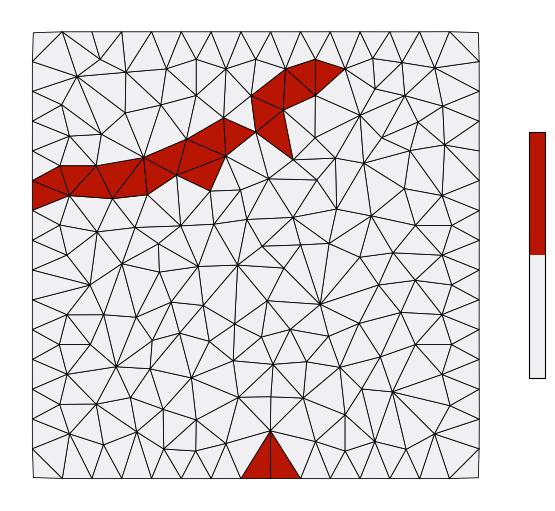

In [12]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_uncertainty_mask_value.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"high_uncertainty_region.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

[Field Metric 1] ROC-AUC: 0.8925 (Closer to 1.0 is better)  
[Field Metric 2] Average Precision (PR-AUC): 0.8558 (Higher is better)  
[Field Metric 3] GT-based Log-CNR: 11.4935 (Higher means better signal contrast)  
[Field Metric 4] GT-based FDR: 1.8389 (Higher means better statistical separability)  
[Field Metric 5] GT-based Suppression Ratio: 165685645269603668312296029699775241583302822330368.0000 (Higher means target is relatively enhanced)  
[Field Metric 5] GT-based Log Suppression Ratio: 50.2193

指标5因为值空间跨度太大,无法适用

---
Information space

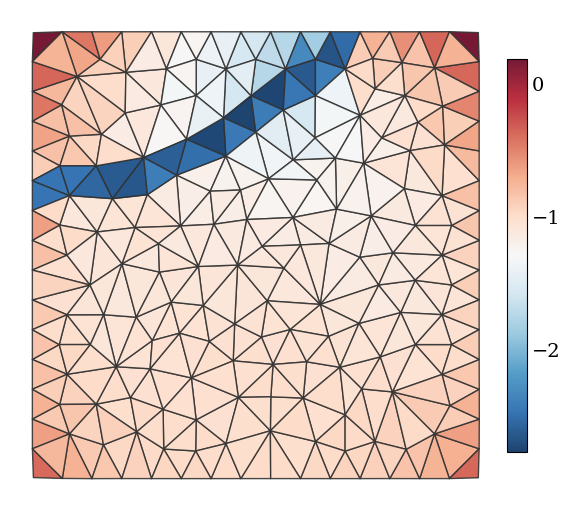

In [4]:
# cmap_custom = sns.color_palette("RdYlBu_r", as_cmap=True)
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.sqrt(np.diag(Y_k))
inform_normalized = np.log10(inform)
v_min, v_max = inform_normalized.min(), inform_normalized.max()

# tick_locs = np.arange(np.ceil(np.log10(v_min)), np.floor(np.log10(v_max))+1)
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im1 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=inform_normalized, shading='flat', 
                    edgecolors='#333333', linewidth=1., alpha=0.9, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.046)
cbar1.ax.tick_params(length=0, labelsize=14)
cbar1.locator = ticker.MultipleLocator(1)

# cbar1.set_ticks(tick_locs)
# cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs])

plt.savefig(f"stiffness_inform.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

[Local Evaluation] (Using GT band as reference)
  Band ROC-AUC: 0.9992
  Band PR-AUC: 0.9974
  Local Robust CNR: 3.0918
  Local FDR: 13.3499
[Global Evaluation]
  [Field Metric 1] ROC-AUC: 0.9998 (Closer to 1.0 is better)
  [Field Metric 2] PR-AUC: 0.9974 (Higher is better)
  [Field Metric 3] Robust CNR: 5.6605 (Higher is better)
  [Field Metric 4] FDR: 28.4226 (Higher is better)
[Global Segmentation Evaluation]
  [Seg Metric 1] Dice:       0.5758
  [Seg Metric 2] IoU:        0.4043
  [Seg Metric 3] Precision:  0.4043
  [Seg Metric 4] Recall:     1.0000
  [Seg Metric 5] Specificity:0.8996
  [Seg Metric 6] F1-score:   0.5758